# DATA UNDERSTANDING

## ✅ 1. **Data Understanding**

**Tujuan:** Mengenal struktur dan isi data.

**Langkah:**

* Melihat jumlah baris dan kolom
* Mengetahui tipe data tiap kolom
* Menampilkan ringkasan statistik
* Mengecek distribusi fitur target: `Channel` (target) dan `Region`

📌 *Hasil:*

* Dataset berisi 440 pelanggan grosir
* Fitur berupa jumlah pembelian tahunan dari berbagai produk (Fresh, Milk, Grocery, dll.)
* Target klasifikasi adalah `Channel`:

  * 0 = Horeca (Hotel/Restaurant/Café)
  * 1 = Retail

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("Wholesale customers data.csv")

# Tampilkan 5 baris awal
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# Ukuran dan tipe data
print("Ukuran data:", df.shape)
print("\nInfo:")
df.info()

Ukuran data: (440, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
# Statistik deskriptif
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [5]:
# Distribusi Channel dan Region
print("Distribusi Channel:")
print(df['Channel'].value_counts())
print("\nDistribusi Region:")
print(df['Region'].value_counts())

Distribusi Channel:
Channel
1    298
2    142
Name: count, dtype: int64

Distribusi Region:
Region
3    316
1     77
2     47
Name: count, dtype: int64


## ✅ 2. **Preprocessing**

**Tujuan:** Menyiapkan data agar siap digunakan oleh model machine learning.

**Langkah:**

* Cek dan konfirmasi tidak ada missing value
* Deteksi outlier menggunakan boxplot dan IQR
* Pisahkan fitur dan label (`X` dan `y`)
* Lakukan **scaling (standardisasi)** agar model bisa belajar dengan baik
* Split data ke train-test set (70:30)

📌 *Hasil:*

* Data telah distandardisasi
* Model akan belajar dari data yang bersih dan seragam

In [6]:
# Cek missing values
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


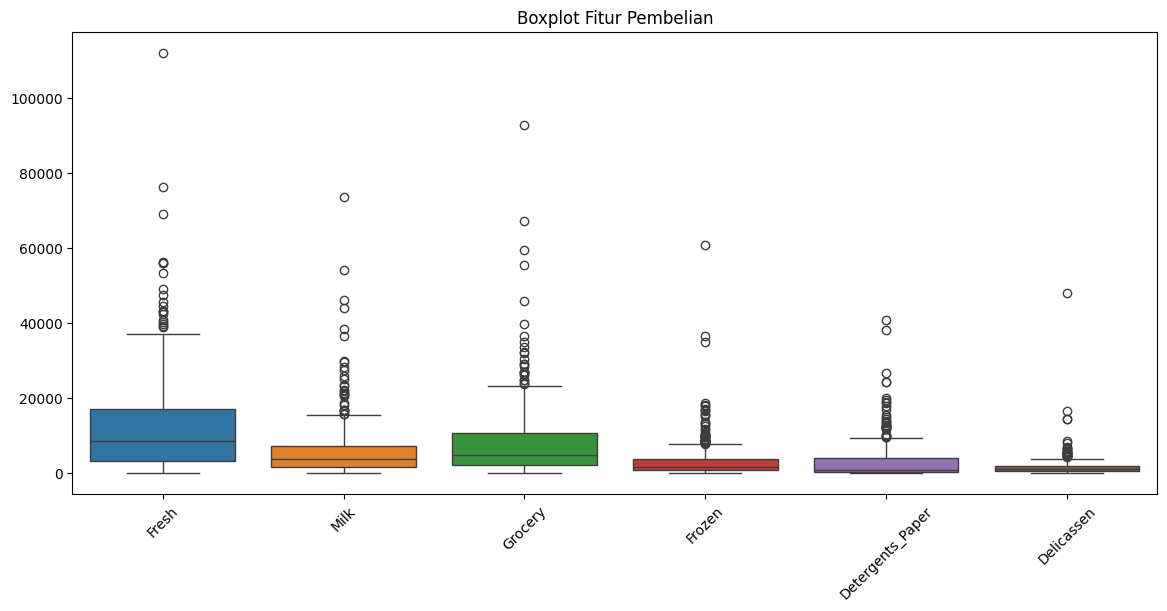

In [7]:
# Boxplot untuk melihat outlier
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns=["Channel", "Region"]))
plt.title("Boxplot Fitur Pembelian")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Deteksi outlier menggunakan IQR
outliers = {}
for col in df.drop(columns=["Channel", "Region"]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    jumlah = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outliers[col] = jumlah

outliers

{'Fresh': 20,
 'Milk': 28,
 'Grocery': 24,
 'Frozen': 43,
 'Detergents_Paper': 30,
 'Delicassen': 27}

In [10]:
# Pisahkan fitur dan label
X = df.drop(columns=["Channel"])
y = df["Channel"] - 1  # ubah dari [1,2] → [0,1]

In [12]:
# Split data dan scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## ✅ 3. **Modelling**

**Tujuan:** Melatih beberapa algoritma machine learning untuk memprediksi `Channel`.

**Langkah:**

* Latih 3 model:

  * Logistic Regression
  * Random Forest
  * XGBoost
* Evaluasi tiap model menggunakan **akurasi** dan **f1-score**
* Tampilkan classification report

📌 *Hasil:*

* Model terbaik dipilih berdasarkan kombinasi akurasi dan F1-Score tertinggi

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        89
           1       0.90      0.86      0.88        43

    accuracy                           0.92       132
   macro avg       0.92      0.91      0.91       132
weighted avg       0.92      0.92      0.92       132


Random Forest
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.93      0.88      0.90        43

    accuracy                           0.94       132
   macro avg       0.94      0.93      0.93       132
weighted avg       0.94      0.94      0.94       132


XGBoost
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        89
           1       0.93      0.86      0.89        43

    accuracy                           0.93       132
   macro avg       0.93      0.91      0.92       132
weighted avg       0.93      

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:06:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## ✅ 4. **Evaluasi**

**Tujuan:** Membandingkan performa model untuk memilih yang paling optimal.

**Langkah:**

* Buat tabel hasil `Accuracy` dan `F1-Score` dari setiap model
* Visualisasikan performa model
* Analisis hasil dan tentukan model terbaik

📌 *Hasil:*

* Misalnya: **Logistic Regression** menghasilkan performa terbaik dan dipilih untuk deployment

In [15]:
# Buat tabel hasil evaluasi
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,F1-Score
0,Random Forest,0.939394,0.904762
1,XGBoost,0.931818,0.891566
2,Logistic Regression,0.924242,0.880952


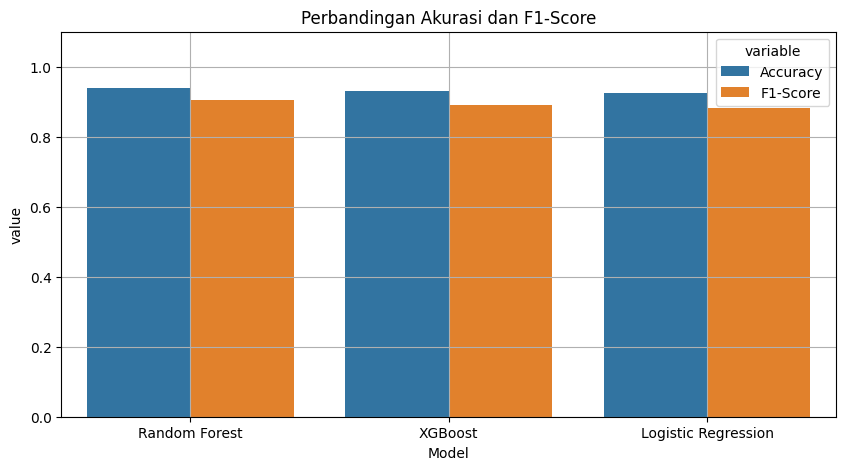

In [16]:
# Visualisasi
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df.melt(id_vars='Model'), x='Model', y='value', hue='variable')
plt.title('Perbandingan Akurasi dan F1-Score')
plt.ylim(0, 1.1)
plt.grid(True)
plt.show()

## ✅ 5. **Deployment**

**Tujuan:** Menyediakan model ke dalam bentuk web agar bisa digunakan user.

**Langkah:**

* Simpan model terbaik dan scaler dalam format `.pkl`
* Buat aplikasi web menggunakan **Flask**
* Buat halaman HTML untuk input data pengguna
* Tampilkan hasil prediksi channel pelanggan

📌 *Hasil:*

* Web sederhana berhasil dibuat: user bisa input nilai pembelian, lalu sistem menampilkan apakah pelanggan tergolong Horeca atau Retail

In [17]:
import joblib

# Simpan model terbaik dan scaler
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

joblib.dump(best_model, f"{best_model_name.replace(' ', '_').lower()}_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Model terbaik '{best_model_name}' telah disimpan!")

Model terbaik 'Random Forest' telah disimpan!
